In [1]:
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
plt.style.use("dark_background")

In [2]:
%matplotlib widget

In [3]:
def parse_data(l:str):
    if len(l) < 10: return "", []
    if l[:5] != "Data:": return "", []
    s = l.split('\t')

    if len(s) < 2: return "", []
    _t = s[0].split(',')
    if len(_t) < 2: return "", []
    _type = _t[0][5:]
    _size = int(_t[1][7:])
    arr = np.fromstring(s[1], sep = ',', dtype=np.uint32)
    if _type == "ENV":
        env_type = np.bitwise_and(arr, 0xF000) >> 12
        env_read = np.bitwise_and(arr, 0x0FFF)
        env_time = np.bitwise_and(arr, 0xFFFF0000) >> 10
        leaftemp_t = env_time[env_type == 4]
        leaftemp = env_read[env_type == 4] / 10
        timestemp_t = env_time[env_type < 4]
        timestemp = env_type[env_type < 4]
        return "ENV", [timestemp_t, timestemp, leaftemp_t, leaftemp]
    elif _type in ["Fluo", "Fluoref", "SUN", "leaf", "730", "730ref"]:
        return _type, [arr]
    else:
        print(_type)

    return "", []

def gen_cmd_arr_line(mode:int, ir:int, num:int, freq:int, actinic:int, sub:int)->list:
    return [mode, ir, num//256, num%256, freq//256, freq%256, actinic, sub]

def ambit_run_arr(cmd_str, port = "COM31"):
    timeout = 300
    s = ''
    _l = 0
    result = {"env_t0": time.time()}

    with serial.Serial("COM31", baudrate=115200) as ser:
        t0 = time.time()
        ser.write(cmd_str.encode())
        while time.time() - t0 < timeout:
            try:
                if ser.in_waiting > 1:
                    c = ser.read()
                    if (c > bytes([0])) and (c < bytes([128])):
                        s += c.decode()
                        _l += 1
                        if (c == b"\n") or (c == b"\r"):
                            l = s
                            s = ''
                            _l = 0
                            if l[:-1] == "BAD COMMAND":
                                timeout = 1
                                continue
                            if l[:-1] == "Data sent":
                                timeout = .1
                                continue
                            #print(l)
                            d_type, data = parse_data(l)
                            if d_type == "ENV":
                                result.update({"env_stamp_t": data[0], "env_stamp": data[1], "env_leaf_t": data[2], "env_leaf": data[3]})
                            elif d_type != "":
                                result.update({d_type: data[0][:-1]})
                else:
                    time.sleep(.1)
            except KeyboardInterrupt:
                break
    return result

def calc_arr_param(cmd: list, persist:bool):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml = 0, []
    for _n, _f in zip(num_pts, mea_feq):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml 


In [4]:
class ambit_run():
    def __init__(self, persist:bool = False) -> None:
        self.cmd_list = []
        self.led_persist = int(persist)
        
    def add(self, mode:int = 2, ir:int = 0, num:int = 100, freq:int = 100, actinic:int = 0, sub:int = 1):
        self.cmd_list += [mode, ir, num//256, num%256, freq//256, freq%256, actinic, sub]
        return
    def run(self):
        cmd_str, self.mea_tml = calc_arr_param(self.cmd_list, self.led_persist)
        self.result = {"env_tl": self.mea_tml, "env_t0": time.time()}
        self.result.update(ambit_run_arr(cmd_str))
        return self.result

    def plot(self):
        result = self.result
        mea_tml = self.mea_tml
        plot_list = [_k for _k in result.keys() if _k[:4] != "env_"]
        fig, axes = plt.subplots(1, len(plot_list) + 1, sharex = True, figsize = (20, 6))
        for n, _p in enumerate(plot_list):
            axes[n + 1].plot(mea_tml[1:], result[_p][1:])
            axes[n + 1].set_title(_p)
        axes[0].plot(mea_tml[1:], (result["Fluo"]/ result["Fluoref"])[1:])
        # axes[0].plot(result['env_stamp_t'][:-1]/854, result['env_stamp'][:-1]* np.mean((result["Fluo"]/ result["Fluoref"])[1:]) + .1)
        ax = axes[0].twinx()
        ax.plot(result['env_leaf_t']/1000, result['env_leaf'], 'r.-')
    


In [ ]:
MPF1 = ambit_run(True)
MPF1.add(num = 10, freq = 5, actinic=0)
MPF1.add(num = 40, freq = 100, actinic=250)  # 0.4s max

MPF1.add(num = 10, freq = 100, actinic=200)  # 0.1s 
MPF1.add(num = 10, freq = 100, actinic=120)  # 0.1s 
MPF1.add(num = 10, freq = 100, actinic=100)  # 0.1s 
MPF1.add(num = 10, freq = 100, actinic=80)  # 0.1s 
MPF1.add(num = 10, freq = 100, actinic=60)  # 0.1s 

MPF1.add(num = 40, freq = 100, actinic=240)
MPF1.add(num = 25, freq = 100, actinic=0)
MPF1.add(num = 50, freq = 10, actinic=0)

MPF1.run()
MPF1.plot()

In [ ]:
ret = MPF1.result
plt.figure()
plt.plot(ret['Fluo'][5:],ret['Fluoref'][5:])

In [ ]:
MPF2 = ambit_run(True)
MPF2.add(num = 25, freq = 100, actinic=250)
MPF2.add(num = 25, freq = 100, actinic=200)
MPF2.add(num = 25, freq = 100, actinic=150)
MPF2.add(num = 25, freq = 100, actinic=100)
MPF2.add(num = 25, freq = 100, actinic=250)
MPF2.add(num = 25, freq = 100, actinic=50)
# ret = MPF2.run()
# MPF2.plot()

In [ ]:
MPF3 = ambit_run(True)
MPF3.add(num = 25, freq = 100, actinic=250)
MPF3.add(num = 25, freq = 100, actinic=200)
MPF3.add(num = 25, freq = 100, actinic=150)
MPF3.add(num = 25, freq = 100, actinic=100)
MPF3.add(num = 25, freq = 100, actinic=250)
MPF3.add(num = 25, freq = 100, actinic=0)
# ret = MPF3.run()
# MPF3.plot()

In [ ]:
RGF1 = ambit_run(True)
RGF1.add(num = 25, freq = 100, actinic=250)
RGF1.add(num = 25, freq = 100, actinic=0)

In [ ]:
ACT1 = ambit_run(True)
ACT1.add(num=100, freq = 20, actinic=50)

AMB1 = ambit_run()
AMB1.add(num=100, freq = 20, actinic=0)

AMB2 = ambit_run()
AMB2.add(num=100, freq = 10, actinic=0)

AMB3 = ambit_run()
AMB3.add(num=100, freq = 5, actinic=0)

In [ ]:
runlist = [MPF1] + [ACT1, MPF2] * 4 + [AMB1, MPF3] * 2 + [AMB2, MPF3] * 3 + [AMB3, RGF1] * 4
fig, axes = plt.subplots(1, 5, sharex = True, figsize = (20, 6))
ax = axes[0].twinx()
results = []
for n in runlist:
    ret = n.run()
    results.append(ret)
    _tl = ret['env_tl']
    _TL = _tl + ret['env_t0']
    plot_list = [_k for _k in ret.keys() if _k[:4] != "env_"]
    for n, _p in enumerate(plot_list):
        axes[n + 1].plot(_TL[1:], ret[_p][1:])
        axes[n + 1].set_title(_p)
    axes[0].plot(_TL[1:], (ret["Fluo"]/ ret["Fluoref"])[1:])
    # axes[0].plot(result['env_stamp_t'][:-1]/854, result['env_stamp'][:-1]* np.mean((result["Fluo"]/ result["Fluoref"])[1:]) + .1)
    ax.plot(ret['env_leaf_t']/1000 + ret['env_t0'], ret['env_leaf'], 'r.')



In [ ]:
fig, axes = plt.subplots(1, 5, sharex = True, figsize = (16, 6))
ax = axes[0].twinx()
for ret in results:
    _tl = ret['env_tl']
    _TL = _tl + ret['env_t0']
    plot_list = [_k for _k in ret.keys() if _k[:4] != "env_"]
    for n, _p in enumerate(plot_list):
        axes[n + 1].plot(_TL[1:], ret[_p][1:])
        axes[n + 1].set_title(_p)
    axes[0].plot(_TL[1:], (ret["Fluo"]/ ret["Fluoref"])[1:])
    
    ax.plot(ret['env_leaf_t']/1000 + ret['env_t0'], ret['env_leaf'], 'r.')

In [ ]:
fig, axes = plt.subplots(1, 1, sharex = True, figsize = (16, 6), facecolor = [0, 0, 0, 0])
ax = axes.twinx()
for ret in results:
    _tl = ret['env_tl']
    _TL = _tl + ret['env_t0']
    axes.plot(_TL[1:], (ret["Fluo"]/ ret["Fluoref"])[1:])
    
    ax.plot(ret['env_leaf_t']/1000 + ret['env_t0'], ret['env_leaf'], 'r.')

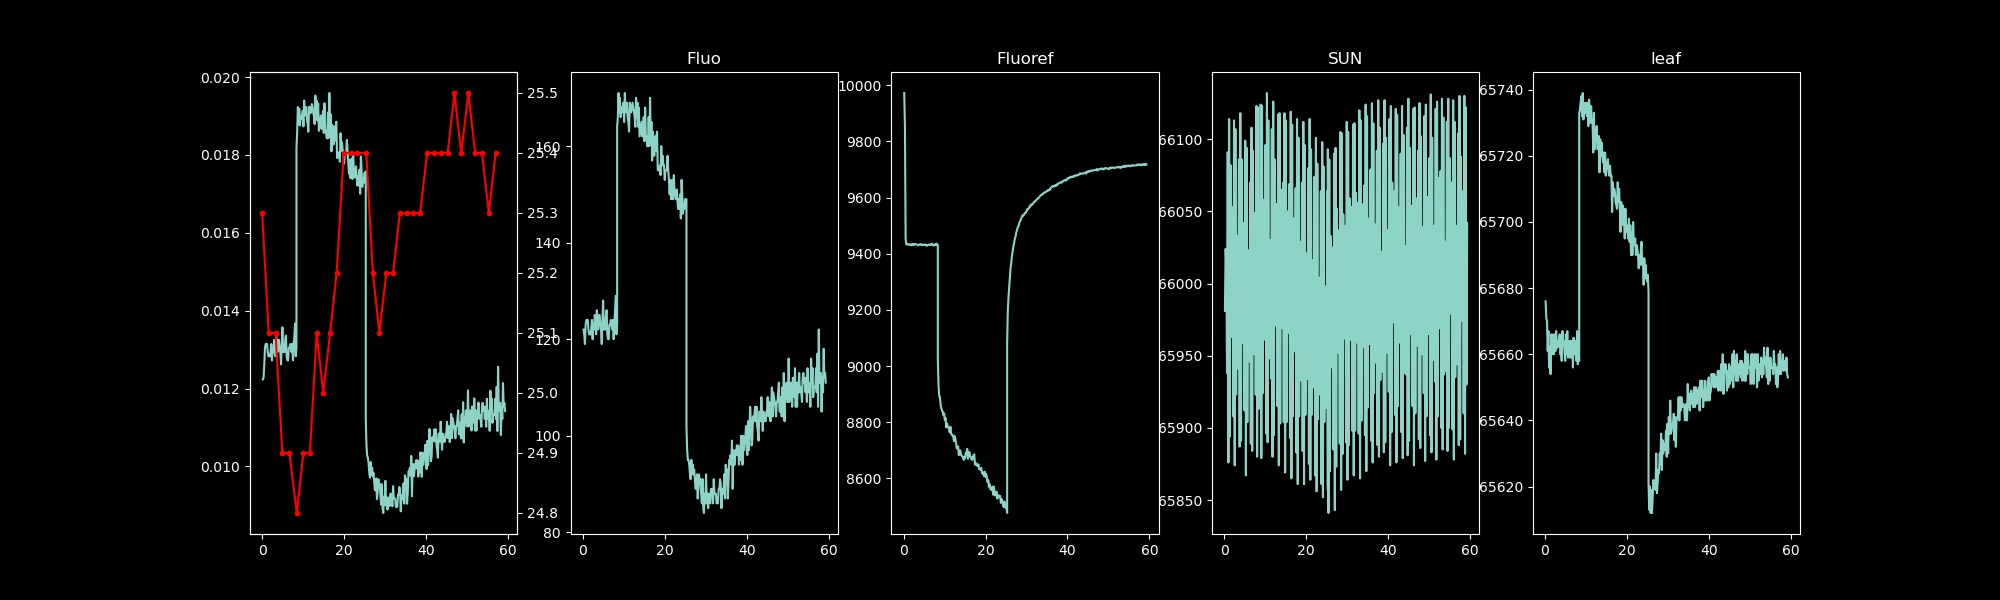

In [26]:
TEMP1 = ambit_run()
TEMP1.add(num=50, freq = 5, actinic=0)
TEMP1.add(num=100, freq = 5, actinic=250)
TEMP1.add(num=200, freq = 5, actinic=0)
ret_M0 = TEMP1.run()
TEMP1.plot()

In [27]:
norm = lambda x: (x - x[-1]) / (x.max() - x[-1])
norm = lambda x:x - x[:4].mean()

C:\Users\hjcbj\AppData\Local\Temp\ipykernel_4868\2471166036.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


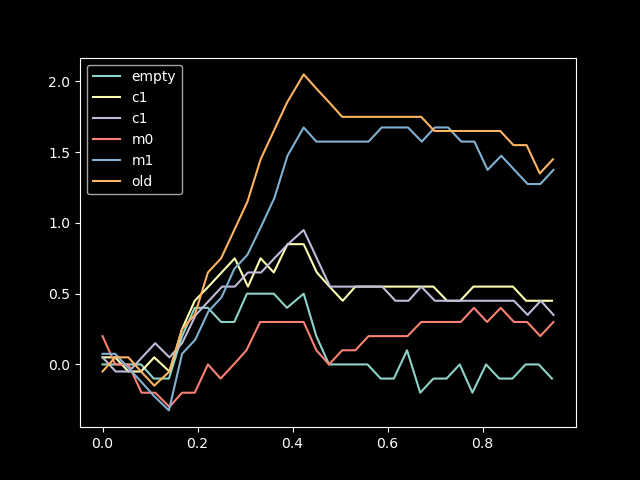

In [29]:
plt.figure()
plt.plot(ret_EPT['env_leaf_t']/60000, norm(ret_EPT['env_leaf']), label = 'empty')
plt.plot(ret_C1['env_leaf_t']/60000, norm(ret_C1['env_leaf']), label = 'c1')
plt.plot(ret_C2['env_leaf_t']/60000, norm(ret_C2['env_leaf']), label = 'c1')

plt.plot(ret_M0['env_leaf_t']/60000, norm(ret_M0['env_leaf']), label = 'm0')
plt.plot(ret_M1['env_leaf_t']/60000, norm(ret_M1['env_leaf']), label = 'm1')


plt.plot(ret_OLD['env_leaf_t']/60000, norm(ret_OLD['env_leaf']), label = 'old')



plt.legend()